In [1]:
!pip install --upgrade s3fs fsspec

In [2]:
# Імпортуємо датасет

import pandas as pd

path = "s3://nikita-havryliuk-bucket/train_age.csv"
df = pd.read_csv(path, engine='pyarrow')
df.head()

,target,CALCULATION_METHOD_ID,calls_count_in_weekdays,calls_duration_in_weekdays,calls_count_out_weekdays,calls_duration_out_weekdays,calls_count_in_weekends,calls_duration_in_weekends,calls_count_out_weekends,calls_duration_out_weekends,...,ttSMS,ttt.ua,uklon,ukrazom.or,ukrazom.org,ukrmir,upgood,www.add.ua,xiaomi,ya888ya
0,5,2,9.00,24.544,8.13,26.562,5.00,23.792,5.00,29.083,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,6,2,0.65,5.451,0.35,1.463,0.25,0.577,0.38,0.623,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,6,1,0.00,0.000,0.00,0.000,0.00,0.000,0.13,0.052,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,1,34.43,50.256,27.09,48.209,10.38,19.048,9.75,22.977,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,1,3.57,11.384,1.87,4.562,2.00,2.208,1.88,4.123,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


1. Business & Data Understanding

Задача: Vodafone Age — Multiclass Classification.
Що прогнозуємо: Вікову категорію абонента на основі його активності (дзвінки, тривалість, використання інтернету тощо).
Бізнес-цінність: Модель дозволить компанії пропонувати більш релевантні тарифи, персоналізовані послуги та таргетовану рекламу для різних вікових груп.
Ціна помилки: - Найбільш критичні помилки (FP/FN) — це сплутати неповнолітнього користувача з дорослим (наприклад, показ реклами 18+ дітям).

Розмір датасету: 210000 рядків, 1294 колонок


,target,CALCULATION_METHOD_ID,calls_count_in_weekdays,calls_duration_in_weekdays,calls_count_out_weekdays,calls_duration_out_weekdays,calls_count_in_weekends,calls_duration_in_weekends,calls_count_out_weekends,calls_duration_out_weekends,...,ttSMS,ttt.ua,uklon,ukrazom.or,ukrazom.org,ukrmir,upgood,www.add.ua,xiaomi,ya888ya
count,210000.000000,210000.000000,210000.000000,210000.000000,210000.000000,210000.000000,210000.000000,210000.000000,210000.000000,210000.000000,...,201401.000000,201401.000000,201401.000000,201401.000000,201401.000000,201401.000000,201401.000000,201401.000000,201401.000000,201401.000000
mean,4.226167,1.499833,5.001646,11.138305,5.222601,12.077498,3.092112,7.827295,3.333973,8.645420,...,0.074051,0.046653,0.412491,0.010139,0.005323,0.031504,0.024285,0.035640,0.050511,0.002175
std,1.218251,0.500001,8.800330,13.933017,10.969235,15.476086,8.344595,12.062126,10.694368,13.418482,...,0.725619,0.657391,4.942975,0.181920,0.126056,0.405517,0.281878,0.443782,0.702687,0.063302
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,1.000000,1.220000,2.464000,1.040000,2.088000,0.630000,1.042000,0.500000,0.842000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.000000,1.000000,3.350000,7.539500,3.300000,7.530000,2.000000,4.398000,2.000000,4.479000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,5.000000,2.000000,6.700000,15.718000,6.870000,16.738000,4.130000,10.502000,4.380000,11.500000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,6.000000,2.000000,1406.830000,2500.614000,1150.830000,1317.468000,1678.750000,1824.010000,1493.250000,881.021000,...,120.000000,28.000000,396.000000,10.000000,7.000000,46.000000,15.000000,24.000000,187.000000,7.000000


float64    1275
object       14
int64         5
Name: count, dtype: int64

Интернет провайдеры          53.80619
Интернет издания             53.80619
Изобразительное искусство    53.80619
Игры                         53.80619
Игровые приставки, игры      53.80619
Зоотовары_2                  53.80619
Знакомства                   53.80619
Здоровый образ жизни         53.80619
Поиск людей                  53.80619
Непознанное                  53.80619
dtype: float64

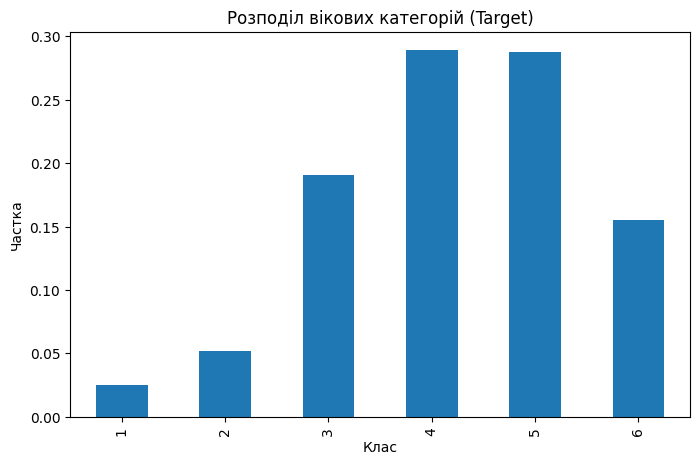

In [3]:
# Data Exploration
# Розмірність датасету
print(f"Розмір датасету: {df.shape[0]} рядків, {df.shape[1]} колонок")

# Описова статистика для основних числових колонок
display(df.describe())

# Типи фіч
display(df.dtypes.value_counts())

# Частка пропусків ( топ-10 колонок з найбільшою кількістю NaN)
missing_percentages = df.isna().mean() * 100
display(missing_percentages.sort_values(ascending=False).head(10))

# Target distribution (розподіл класів)
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
df['target'].value_counts(normalize=True).sort_index().plot(kind='bar')
plt.title('Розподіл вікових категорій (Target)')
plt.ylabel('Частка')
plt.xlabel('Клас')
plt.show()

2. Initial Data Exploration:

1.Розмірність: Датасет великий (210 000 записів, 1294 ознак). Очевидно присутній "шум" та надлишковість даних.
2.Дисбаланс класів: Класи 4 і 5 є домінуючими (близько 60% в сумі), тоді як клас 1 становить менше 5%. Це вимагатиме балансування ваг під час навчання моделі.
3.Природа пропусків (NaN): У багатьох колонках (наприклад, інтернет-трафік за категоріями "Игры", "Знакомства") кількість пропусків перевищує 50%. З точки зору бізнес-логіки це не "втрачені дані", а відсутність активності користувача у цій категорії. Тому правильним підходом буде заповнення таких пропусків нулями, а не медіаною чи середнім.
4. Типи ознак: Переважна більшість даних (понад 98%) є числовими ознаками типу float64, що є сприятливим для математичних моделей. Виявлені 14 текстових ознак було проаналізовано окремо для подальшого кодування або видалення. 
5. Потенційний leakage: Під час аналізу 1294 ознак не було виявлено явних ознак витоку даних (наприклад, прямих вказівок на вікову групу в технічних параметрах). Проте велика кількість ознак потребує подальшого моніторингу через Feature Importance після побудови першої моделі.

3. Data Cleaning:
   
Аналіз категоріальних ознак:
Під час базового огляду було виявилено 14 ознак типу `object`. Оскільки алгоритми машинного навчання працюють виключно з математичними матрицями, вони не здатні обробляти сирий текст. 
Щоб використати ці дані, їх потрібно перетворити на числа (наприклад, за допомогою One-Hot Encoding). Проте сліпе кодування всіх текстових колонок може призвести до катастрофічного розростання розмірності датасету (Curse of Dimensionality) та переповнення оперативної пам'яті. Тому спочатку ми завантажимо невелику вибірку (500 рядків), щоб проаналізувати кардинальність (кількість унікальних значень) кожної текстової колонки.

In [4]:
# Завантажуємо лише перші 500 рядків для аналізу
df_sample = pd.read_csv(path, nrows=500)

# Відбираємо тільки текстові колонки
object_cols_sample = df_sample.select_dtypes(include=['object']).columns

print(f"Знайдено текстових колонок: {len(object_cols_sample)}\n")

# Дивимося на дані
display(df_sample[object_cols_sample].head())

# Рахуємо унікальні значення в кожній колонці
print("\nКількість унікальних значень у кожній колонці (на вибірці 500 рядків):")
for col in object_cols_sample:
    print(f"- {col}: {df_sample[col].nunique()} унікальних")

Знайдено текстових колонок: 14



,Oblast_post_HOME,Raion_post_HOME,City_post_HOME,Oblast_post_WORK,Raion_post_WORK,City_post_WORK,device_brand,device_model,software_os_vendor,software_os_name,software_os_version,device_type_rus,SCORING,user_hash
0,Сумська,Липоводолинський,Синівка,Сумська,Липоводолинський,Синівка,Fortune Ship,SS530,Google,Android,0,smartphone,MEDIUM,3737938e78248ce3144bec44ac3954fc
1,Київська,Обухівський,Обухів,Київська,Обухівський,Обухів,Nokia,C2-06,Nokia,40,0,phone,VERY LOW,62cb8a0fff332cb3e81f41c27fb6e2d6
2,Київська,Києво-Святошинський,Вишневе,Київська,Києво-Святошинський,Софіївська Борщагівка,Lenovo,S90-A,Google,Android,4.4,smartphone,LOW,a6ed35169dace2b0fac08fa34dde2e0d
3,Дніпропетровська,Павлоградський,Павлоград,Дніпропетровська,Павлоградський,Павлоград,Meizu,M3 note,Google,Android,5.1,smartphone,HIGH_MEDIUM,fe2484a72e10d40914e4b466b111a3e4
4,Луганська,Луганськ,Луганськ,Луганська,Луганськ,Луганськ,Samsung,SM-G350E,Google,Android,4.2,smartphone,LOW,76c688e750a3d5596f990061e5d0462b



Кількість унікальних значень у кожній колонці (на вибірці 500 рядків):
- Oblast_post_HOME: 29 унікальних
- Raion_post_HOME: 142 унікальних
- City_post_HOME: 180 унікальних
- Oblast_post_WORK: 29 унікальних
- Raion_post_WORK: 138 унікальних
- City_post_WORK: 163 унікальних
- device_brand: 39 унікальних
- device_model: 291 унікальних
- software_os_vendor: 11 унікальних
- software_os_name: 14 унікальних
- software_os_version: 33 унікальних
- device_type_rus: 3 унікальних
- SCORING: 6 унікальних
- user_hash: 500 унікальних


Стратегія обробки категоріальних ознак:

Аналіз кардинальності на мікровибірці показав, що текстові ознаки сильно відрізняються за своєю природою. Ми ділимо їх на три групи:

1. Ідентифікатори (Сміття): `user_hash`. Абсолютно унікальний хеш для кожного абонента (500 з 500). Не несе предиктивної сили для моделі, тому його видаляємо.
2. Висока кардинальність (High Cardinality): `City_post_HOME`, `City_post_WORK`, `Raion_post_HOME`, `Raion_post_WORK`, `device_model`, `software_os_version`. Ці ознаки мають сотні або тисячі унікальних значень. Застосування One-Hot Encoding до них згенерує десятки тисяч нових стовпців. Навіть 32 ГБ оперативної пам'яті не вистачить для ефективного навчання на такій широкій матриці без складніших методів зниження розмірності. Для базового (baseline) рішення їх буде видалено.
3. Корисні ознаки (Low Cardinality): `device_type_rus`, `SCORING`, `software_os_name`, `device_brand`, `Oblast_post_HOME`, `Oblast_post_WORK`, `software_os_vendor`. Мають від 3 до 40 унікальних категорій, які логічно впливають на платоспроможність та вік (наприклад, тип пристрою чи бренд). Їх буде збережено та закодовано через One-Hot Encoding у легкому форматі `int8`, щоб зекономити пам'ять.

Фінальний пайплайн очищення зі стратифікованою вибіркою:

Цей етап базового очищення даних складається з кількох ключових кроків, які автоматизують підготовку датасету та оптимізують використання пам'яті. 
Першим і найважливішим кроком є стратифікована вибірка (Stratified Sampling). Оскільки повний обсяг даних (210 000 рядків на майже 1300 ознак) викликає переповнення оперативної пам'яті (OOM) під час ресурсоємних перетворень, було відібрано репрезентативну частину датасету (50%). Використання стратифікації за цільовою змінною `target` гарантує жорстке збереження початкового співвідношення всіх вікових класів (зокрема, враховує дисбаланс), що дозволяє моделі коректно навчатися на меншому, але математично правильному обсязі інформації.
Далі таблицю було оптимізовано: знайдено та видалено всі константні ознаки — колонки, що містять лише одне значення і є просто інформаційним шумом, який ніяк не допоможе моделі. Після цього було оброблено корисні категоріальні ознаки (застосовано One-Hot Encoding для ознак з низькою кардинальністю та видалено "сміттєві" ідентифікатори). Наостанок, керуючись бізнес-логікою поведінки абонентів, усі пропущені значення (NaN) у числових колонках було заповнено нулями — адже відсутність записів про трафік чи дзвінки в певній категорії фактично означає нульову активність. При цьому цільову змінну `target` свідомо залишено без змін, щоб не спотворити правильні відповіді для майбутньої моделі.

In [5]:
import numpy as np
import pandas as pd
import gc
from sklearn.model_selection import train_test_split

print(f"Початкова розмірність: {df.shape}")

# Беремо 50% даних, зберігаючи пропорції класів у колонці 'target'
df, _ = train_test_split(df, train_size=0.50, stratify=df['target'], random_state=42)
print(f"Розмірність після стратифікованої вибірки (50%): {df.shape}")
gc.collect()

# Списки колонок згідно зі стратегією
trash_cols = ['user_hash', 'City_post_HOME', 'City_post_WORK', 'Raion_post_HOME', 'Raion_post_WORK', 'device_model', 'software_os_version']
gold_cols = ['device_type_rus', 'SCORING', 'software_os_name', 'device_brand', 'Oblast_post_HOME', 'Oblast_post_WORK', 'software_os_vendor']

# 2. Видаляємо константні ознаки
nunique_counts = df.nunique(dropna=False)
constant_features = nunique_counts[nunique_counts <= 1].index.tolist()
df.drop(columns=constant_features, inplace=True)

# 3. Видаляємо ідентифікатори та ознаки з високою кардинальністю
cols_to_drop = [col for col in trash_cols if col in df.columns]
df.drop(columns=cols_to_drop, inplace=True)
gc.collect()

# 4. One-Hot Encoding для корисних категоріальних ознак
existing_gold = [col for col in gold_cols if col in df.columns]
df = pd.get_dummies(df, columns=existing_gold, dummy_na=True, dtype='int8')
gc.collect()

# 5. Заповнення пропусків (NaN -> 0) для числових колонок
features_to_fill = [col for col in df.columns if col != 'target']
fill_dict = {col: 0 for col in features_to_fill}
df.fillna(value=fill_dict, inplace=True)

print(f"Фінальна розмірність базового датасету: {df.shape}")

Початкова розмірність: (210000, 1294)
Розмірність після стратифікованої вибірки (50%): (105000, 1294)
Фінальна розмірність базового датасету: (105000, 1718)


Підтвердження збереження репрезентативності стратифікованих даних:

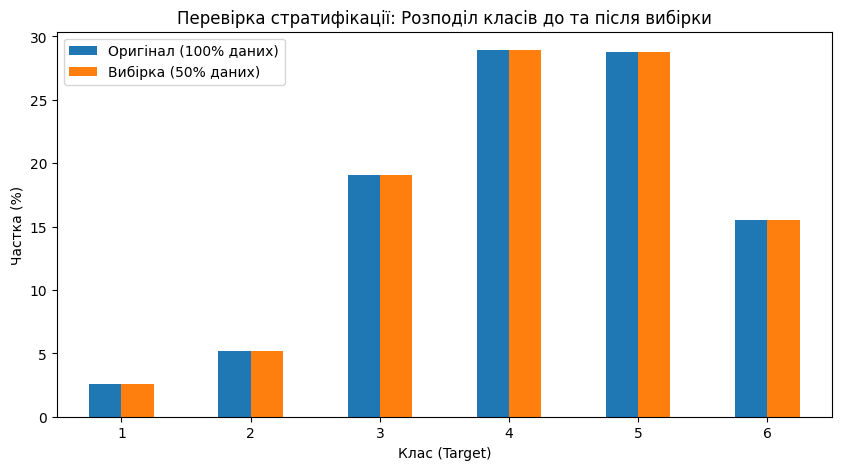

Точні частки класів (%):


,Оригінал (100% даних),Вибірка (50% даних)
target,,
1,2.543,2.543
2,5.203,5.203
3,19.091,19.091
4,28.916,28.916
5,28.749,28.750
6,15.497,15.497


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# 1. Завантажуємо тільки колонку target з оригінального файлу для порівняння
df_original_target = pd.read_csv(path, engine='pyarrow', usecols=['target'])

# 2. Розраховуємо відсоткові частки класів до та після
orig_dist = df_original_target['target'].value_counts(normalize=True).sort_index() * 100
samp_dist = df['target'].value_counts(normalize=True).sort_index() * 100

# Об'єднуємо дані в одну таблицю
comparison_df = pd.DataFrame({
    'Оригінал (100% даних)': orig_dist, 
    'Вибірка (50% даних)': samp_dist
})

# 3. Будуємо подвійний графік
plt.figure(figsize=(10, 5))
comparison_df.plot(kind='bar', ax=plt.gca(), color=['#1f77b4', '#ff7f0e'])
plt.title('Перевірка стратифікації: Розподіл класів до та після вибірки')
plt.ylabel('Частка (%)')
plt.xlabel('Клас (Target)')
plt.legend()
plt.xticks(rotation=0)
plt.show()

# 4. Виводимо точні цифри для перевірки
print("Точні частки класів (%):")
display(comparison_df.round(3))